<a href="https://colab.research.google.com/github/vempaliakhil96/makemore/blob/main/nbs/02-neural-network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from IPython.display import Markdown
import torch
import torch.nn.functional as F
import string
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

%matplotlib inline

## data

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    with open("../data/usnames.txt", "r") as f:
        names = f.readlines()
except:
    with open("/content/drive/MyDrive/usnames.txt", "r") as f:
        names = f.readlines()
names = [n.strip() for n in names]

Mounted at /content/drive


In [3]:
names[:3]

['emma', 'olivia', 'ava']

## tokenize

In [4]:
tok2idx = {c: i for i, c in enumerate('.' + string.ascii_lowercase)}
idx2tok = {i: c for c, i in tok2idx.items()}

## modeling

In [5]:
emb_sz = 3
ctx_len = 2
lr = 0.1

In [6]:
X, Y = [], []

for name in names:
    ctx = ['.'] * ctx_len
    for c in name + '.':
        x = [tok2idx[c] for c in ctx]
        y = tok2idx[c]
        ctx.append(c); ctx.pop(0)
        X.append(x); Y.append(y)

X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 100, generator=g)
b1 = torch.randn(100, generator=g)

# output layer
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

number of parameters = 3508


In [8]:
for p in params: p.requires_grad = True

In [9]:
for i in range(1000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, X.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[X[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lr*p.grad

print(loss.item())

2.542477607727051


In [10]:
# calculating the total loss

X_emb = word_embeddings[X]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.6911, grad_fn=<NllLossBackward0>)

### figuring out a good learning rate

In [11]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [12]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 100, generator=g)
b1 = torch.randn(100, generator=g)

# output layer
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

for p in params: p.requires_grad = True

number of parameters = 3508


In [13]:
losses = []
for i in range(1000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, X.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[X[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lrs[i]*p.grad

    # track
    losses.append(loss.item())

print(loss.item())

7.694077968597412


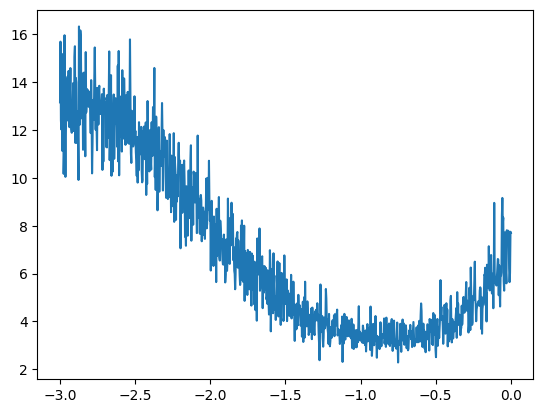

In [14]:
plt.plot(lre, losses);

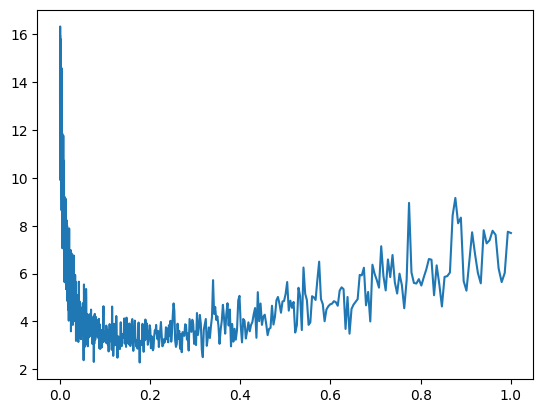

In [15]:
plt.plot(lrs, losses);

### making data splits

In [16]:
def build_dataset(names, ctx_len=ctx_len):
    X, Y = [], []

    for name in names:
        ctx = ['.'] * ctx_len
        for c in name + '.':
            x = [tok2idx[c] for c in ctx]
            y = tok2idx[c]
            ctx.append(c); ctx.pop(0)
            X.append(x); Y.append(y)

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr, Ytr = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xte, Yte = build_dataset(names[n2:])

In [17]:
Xtr.shape, Xdev.shape, Xte.shape

(torch.Size([182589, 2]), torch.Size([22743, 2]), torch.Size([22814, 2]))

### modeling contd.

In [18]:
emb_sz = 2
ctx_len = 2
lr = 0.001

In [19]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 300, generator=g)
b1 = torch.randn(300, generator=g)

# output layer
W2 = torch.randn(300, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

for p in params: p.requires_grad = True

number of parameters = 9681


In [20]:
steps = []
losses = []
for i in range(10000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[Xtr[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ixs])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lr*p.grad

    # track
    steps.append(i)
    losses.append(loss.item())



print(loss.item())

3.9214022159576416


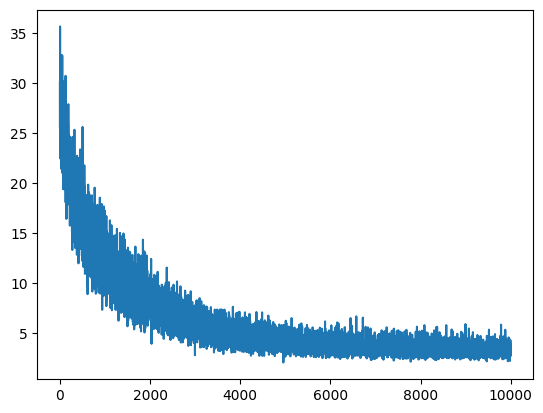

In [21]:
plt.plot(steps, losses);

In [22]:
# calculating the loss on full training set

X_emb = word_embeddings[Xtr]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(3.2878, grad_fn=<NllLossBackward0>)

In [23]:
# calculating the loss on validation set

X_emb = word_embeddings[Xdev]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(3.2832, grad_fn=<NllLossBackward0>)

### visualizing the embeddings

In [24]:
word_embeddings.shape

torch.Size([27, 2])

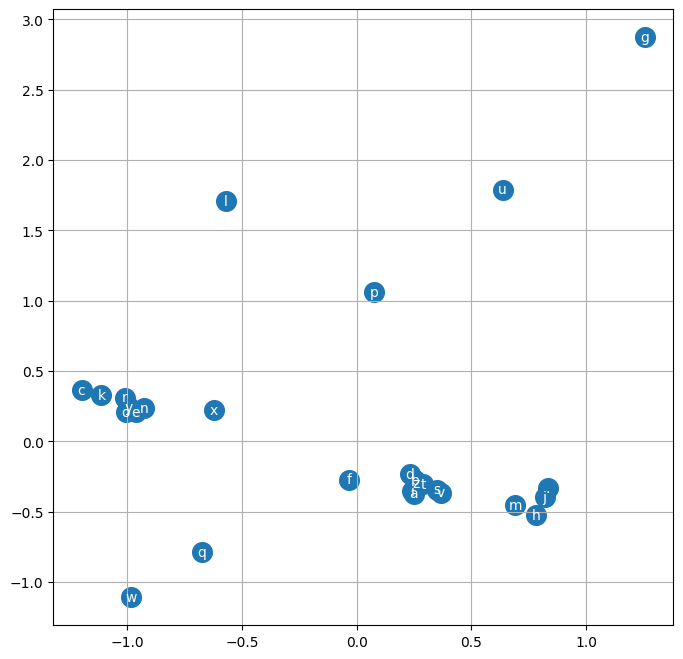

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(word_embeddings[:, 0].data, word_embeddings[:, 1].data, s=200)
for i in range(word_embeddings.shape[0]):
    plt.text(word_embeddings[i, 0].item(), word_embeddings[i, 1].item(), idx2tok[i], ha="center", va="center", color="white")
plt.grid("minor")

### scaling up embedding size

In [40]:
emb_sz = 10
ctx_len = 3

In [41]:
Xtr, Ytr = build_dataset(names[:n1], ctx_len=ctx_len)
Xdev, Ydev = build_dataset(names[n1:n2], ctx_len=ctx_len)
Xte, Yte = build_dataset(names[n2:], ctx_len=ctx_len)

In [42]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 200, generator=g)
b1 = torch.randn(200, generator=g)

# output layer
W2 = torch.randn(200, 27, generator=g) * 0.01
b2 = torch.randn(27, generator=g) * 0.01

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

for p in params: p.requires_grad = True

number of parameters = 11897


In [43]:
steps = []
losses = []
lr = 0.1
for i in tqdm(range(200_000), total=200_000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[Xtr[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ixs])

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    if i > 100_000: lr = 0.01
    if i > 150_000: lr = 0.001
    for p in params:
        p.data += -lr*p.grad

    # track
    steps.append(i)
    losses.append(loss.log10().item())



print(loss.item())

  0%|          | 0/200000 [00:00<?, ?it/s]

1.9555102586746216


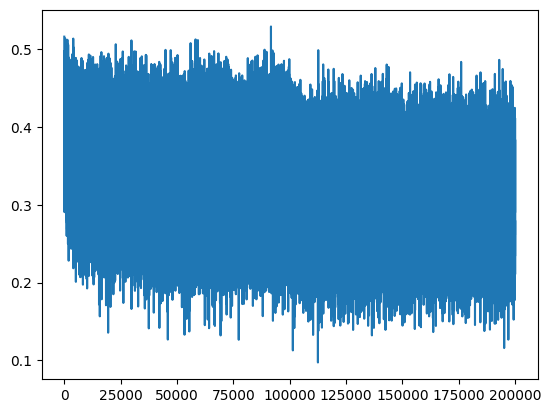

In [44]:
plt.plot(steps, losses);

In [45]:
# calculating the loss on full training set

X_emb = word_embeddings[Xtr]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0624, grad_fn=<NllLossBackward0>)

In [46]:
# calculating the loss on validation set

X_emb = word_embeddings[Xdev]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1320, grad_fn=<NllLossBackward0>)

### sampling from the model

In [47]:
g = torch.Generator().manual_seed(2147483647)
for i in range(25):
    out = []
    ctx = ['.']*ctx_len
    while True:
        emb = word_embeddings[torch.tensor([tok2idx[t] for t in ctx])]
        h = torch.tanh(emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        tok = idx2tok[ix]
        ctx.append(tok); ctx.pop(0)
        out.append(tok)
        if tok == '.': break
    print(''.join(out))

dexzadiegh.
makile.
kayhammilimitta.
nylandrika.
da.
samiyah.
javer.
got.
shi.
ziellavo.
keya.
daren.
emiless.
suhaiavion.
rat.
spristine.
viah.
asu.
dedric.
neilha.
alaisa.
jarrienne.
azer.
dest.
fir.
